# Experiment No: 3
## Title: Create a multiclass classification model to predict wine quality based on chemical properties. Dataset: Wine Quality Dataset (UCI)

###Step 1  Import all the necessary library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###Step 2 :  Load the dataset

In [ ]:
url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"


We use sep=';' because the values in that specific data file are separated by semicolons (;) instead of the standard commas (,).

In [ ]:
df = pd.read_csv(url_red, sep =";")

In [ ]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


###Step 3 : Data Exploration and Cleaning

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
df['quality'].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


###Step 4 Data Preparation :

1.   Visualizing the Target Variable





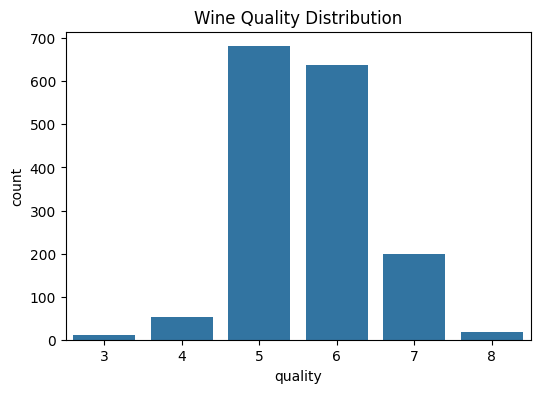

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='quality', data=df)
plt.title("Wine Quality Distribution")
plt.show()


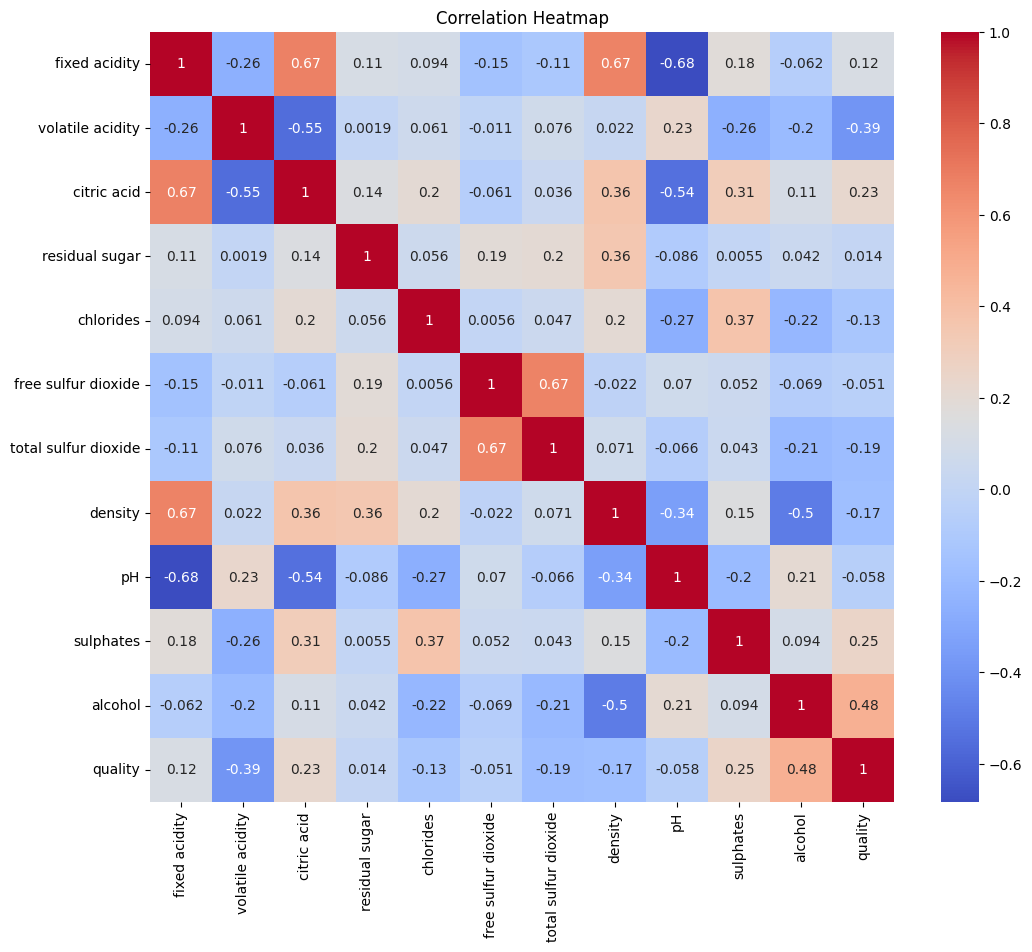

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



2. Separate Features (X) and Target (y)


In [ ]:
X = df.drop('quality', axis=1)
y = df['quality']

In [ ]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [ ]:
y

,quality
0,5
1,5
2,5
3,6
4,5
...,...
1594,5
1595,6
1596,6
1597,5



3.  Split Data for Training and Testing







In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
len(X_train)

1279

In [ ]:
len(X_test)

320

###Step 5 Model Training:


1.  Choose and Train a Model




In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)


2.   Make Predictions on the Test Data



In [ ]:
y_pred = model.predict(X_test)

look at the first 5 predictions our model made



And compare them to the first 5 actual answers



In [ ]:
print("First 5 predictions:", y_pred[:5])
print("First 5 actual answers:", y_test.head().values)

First 5 predictions: [5 5 5 5 6]
First 5 actual answers: [6 5 6 5 6]


###Step 6: Evaluate the Predictions

In [ ]:
from sklearn.metrics import accuracy_score, classification_report


accuracy = accuracy_score(y_test, y_pred)
print ("accuracy", accuracy)

accuracy 0.659375


In [ ]:
print(" Classification Report ")
print(classification_report(y_test, y_pred, zero_division=0))

 Classification Report 
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.75      0.73       130
           6       0.63      0.69      0.66       132
           7       0.63      0.52      0.57        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320



Our model achieved an accuracy of 66%.

The countplot shows that the dataset is imbalanced.

To address this imbalance, we use SMOTE (Synthetic Minority Over-sampling Technique).

SMOTE helps by creating synthetic samples for the minority class, which balances the dataset and improves model performance.

###Step 7:  handling imbalanced data



*  SMOTE is the tool from the imblearn library that creates synthetic examples for minority classes
*  Counter is a handy Python class that counts occurrences


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter


In [ ]:
print("Original training set shape:", Counter(y_train))

Original training set shape: Counter({5: 551, 6: 506, 7: 157, 4: 43, 8: 13, 3: 9})


 Create the SMOTE object

In [ ]:
smote = SMOTE(random_state=42)

Apply SMOTE to our training data

In [ ]:
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

 Display the new class distribution AFTER SMOTE and before SMOTE

In [ ]:
print("Original training set shape:", Counter(y_train))
print("Resampled training set shape: ",Counter(y_train_resampled))

Original training set shape: Counter({5: 551, 6: 506, 7: 157, 4: 43, 8: 13, 3: 9})
Resampled training set shape:  Counter({6: 551, 5: 551, 4: 551, 7: 551, 8: 551, 3: 551})



  Train the new model on the balanced (resampled) training data

In [ ]:
from sklearn.ensemble import RandomForestClassifier

balanced_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
balanced_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

In [ ]:
new_predictions = balanced_model.predict(X_test)

Evalution of the new model

In [ ]:
new_accuracy = accuracy_score(y_test, new_predictions)
print("Original Model Accuracy: ",accuracy)
print("New Balanced Model Accuracy: " ,new_accuracy)

Original Model Accuracy:  0.659375
New Balanced Model Accuracy:  0.61875


In [ ]:
print("New Classification Report")
print(classification_report(y_test, new_predictions, zero_division=0))

New Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.16      0.30      0.21        10
           5       0.72      0.68      0.70       130
           6       0.66      0.58      0.62       132
           7       0.55      0.67      0.60        42
           8       0.17      0.20      0.18         5

    accuracy                           0.62       320
   macro avg       0.38      0.41      0.39       320
weighted avg       0.65      0.62      0.63       320

